In [1]:
!pip3 install -q gymnasium[classic-control]

import os
import sys
import pandas as pd
from IPython.display import clear_output

import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm, trange

%matplotlib inline

SEED = 42

if "google.colab" in sys.modules and not os.path.exists(".setup_complete"):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ["DISPLAY"] = ":1"


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


def seed_everything(env, seed=None):
    if seed is None:
        seed = SEED
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    env.reset(seed=seed)


def visualize_agent(env, agent, max_steps=100, delay=0.1):
    """
    Visualize the agent's behavior in the environment.

    Args:
        env: The environment
        agent: The trained agent
        max_steps: Maximum number of steps to take
        delay: Time delay between steps for visualization
    """
    s, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # Render the environment
        clear_output(True)
        plt.figure(figsize=(8, 6))
        plt.imshow(env.render())
        plt.title(f"Step: {step}, Total Reward: {total_reward:.2f}")
        plt.axis("off")
        plt.show()

        # Get action from the agent
        a = agent.get_best_action(s)  # Use best action for visualization

        # Take a step in the environment
        next_s, r, done, _, _ = env.step(a)

        # Update state and reward
        s = next_s
        total_reward += r

        # Add delay for better visualization
        time.sleep(delay)

        if done:
            # Show final state
            clear_output(True)
            plt.figure(figsize=(8, 6))
            plt.imshow(env.render())
            plt.title(f"Final State - Steps: {step + 1}, Total Reward: {total_reward:.2f}")
            plt.axis("off")
            plt.show()
            break


def benchmark_agents(
    exp_setups,
    num_episodes=1000,
    plot_every=100,
    t_max=10000,
    span=100,
    patch_every=None,
    patch_foo=None,
    num_seeds=3,
):
    all_rewards = {}
    envs = {exp_setup["name"]: exp_setup["env"]() for exp_setup in exp_setups}
    agents_buiders = {exp_setup["name"]: exp_setup["agent_builder"] for exp_setup in exp_setups}
    train_foo = {exp_setup["name"]: exp_setup["train_foo"] for exp_setup in exp_setups}

    for seed in range(num_seeds):
        SEED = seed + 42  # Using different seeds
        agents = {agent_name: agent() for agent_name, agent in agents_buiders.items()}

        # Create a separate environment for each agent using the env function
        for agent_name, agent in agents.items():
            agents[agent_name].env = envs[agent_name]

        seed_rewards = {agent_name: [] for agent_name in agents_buiders}

        # Seed each environment separately
        for agent_name in agents:
            seed_everything(envs[agent_name], seed=SEED)

        tbar = trange(num_episodes)
        tbar.set_description(f"Seed {seed + 1}/{num_seeds}")
        for i in tbar:
            for agent_name, agent in agents.items():
                seed_rewards[agent_name].append(train_foo[agent_name](envs[agent_name], agent))
            if i % 10 == 0:
                tbar.set_postfix({agent_name: seed_rewards[agent_name][-1] for agent_name in agents}, refresh=True)

        # Store rewards for this seed
        for agent_name, rewards_list in seed_rewards.items():
            if agent_name not in all_rewards:
                all_rewards[agent_name] = []
            all_rewards[agent_name].append(rewards_list)

        # Average rewards across seeds
        avg_rewards = {
            agent_name: np.mean(np.array(seed_results), axis=0) for agent_name, seed_results in all_rewards.items()
        }

        # Calculate standard deviation for confidence intervals
        std_rewards = {
            agent_name: np.std(np.array(seed_results), axis=0) for agent_name, seed_results in all_rewards.items()
        }

        # Plot average performance across seeds with confidence tubes
        clear_output(True)
        plt.figure(figsize=(10, 6))
        for agent_name, rewards_list in avg_rewards.items():
            mean_rewards = moving_average(rewards_list, span=span)
            std_rewards_smoothed = moving_average(std_rewards[agent_name], span=span)

            # Plot mean line
            plt.plot(mean_rewards, label=f"{agent_name} (avg of {num_seeds} seeds)")

            # Plot confidence tubes (mean ± std)
            plt.fill_between(
                range(len(mean_rewards)),
                mean_rewards - std_rewards_smoothed,
                mean_rewards + std_rewards_smoothed,
                alpha=0.2,
            )

            # Draw solid contour lines for the confidence tube borders
            plt.plot(range(len(mean_rewards)), mean_rewards - std_rewards_smoothed, "--", color="gray", alpha=0.7)
            plt.plot(range(len(mean_rewards)), mean_rewards + std_rewards_smoothed, "--", color="gray", alpha=0.7)

        plt.title(
            f"{envs[list(envs.keys())[0]].spec.id} - Average performance across {num_seeds} seeds with confidence intervals"
        )
        plt.legend()
        plt.show()

    return avg_rewards

zsh:1: no matches found: gymnasium[classic-control]
Starting virtual X frame buffer: Xvfb../xvfb: line 24: start-stop-daemon: command not found
.


## Seminar: Q-learning

Эта тетрадь поможет вам в реализации простого алгоритма Q-learning.

Вам необходимо внедрить QLearningAgent (следуйте инструкциям для каждого метода) и использовать его в ряде тестов, приведенных ниже.

**Совет**: Для обеспечения воспроизводимости используйте встроенный в среду генератор случайных чисел.

In [2]:
import math
import random
from collections import defaultdict

import numpy as np


class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, env):
        """
        Q-Learning Agent
        основан на https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Переменных экземпляра, к которым у вас есть доступ
          - self.epsilon : вероятность исследования
          - self.alpha : learning rate
          - self.discount : discount rate aka gamma

        Функции, которые вы должны использовать
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        
        !!!Важно!!!
        Примечание: пожалуйста, избегайте использования self._qValues напрямую.
            Для этого есть специальный self.get_qvalue/set_qvalue.
        """

        self.env = env
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_legal_actions(self, _state):
        return list(range(self.env.action_space.n))

    def get_qvalue(self, state, action):
        """Returns Q(state,action)"""
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """Sets the Qvalue for [state,action] to the given value"""
        self._qvalues[state][action] = value

    # ---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Рассчитайте оценку V(s) вашего агента, используя текущие значения Q
        V(s) = max_over_action Q(состояние, действие) по сравнению с возможными действиями.
        Примечание: пожалуйста, примите во внимание, что значения q могут быть отрицательными.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # <YOUR CODE HERE>
        value = max(self.get_qvalue(state, a) for a in possible_actions)

        # </END OF YOUR CODE>

        return value

    def update(self, state, action, reward, next_state, *args, **kwargs):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        # <YOUR CODE HERE>
        new_q_value = (1 - learning_rate) * self.get_qvalue(state, action) + \
            learning_rate * (reward + gamma * self.get_value(next_state))

        # </END OF YOUR CODE>

        self.set_qvalue(state, action, new_q_value)

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # <YOUR CODE HERE>
        best_action, maxq = possible_actions[0], self.get_qvalue(state, possible_actions[0])
        for a in possible_actions[1:]:
            q = self.get_qvalue(state, a)
            if q > maxq:
                maxq = q
                best_action = a
        # </END OF YOUR CODE>

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list).
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability

        Вычислите действие, которое необходимо предпринять в текущем состоянии, включая исследование.
        С вероятностью self.epsilon мы должны предпринять случайное действие.
            в противном случае - наилучшее политическое действие (self.get_best_action).

        Примечание: Для случайного выбора из списка используйте random.choice(список).
              Чтобы выбрать значение True или False с заданной вероятностью, сгенерируйте одинаковое число в [0, 1]
              и сравните его с вашей вероятностью.
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)
        action = self.get_best_action(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        # Tip: Use self.env.np_random.random() to generate a random number
        # <YOUR CODE HERE>
        if self.env.np_random.random() < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        # </END OF YOUR CODE>

        return chosen_action

### Try it on taxi

Here we use the Q-Learning agent on the Taxi-v3 environment from OpenAI gym.
You will need to complete a few of its functions.

In [3]:
import gymnasium as gym

env = gym.make("Taxi-v3", render_mode="rgb_array")

n_actions = env.action_space.n

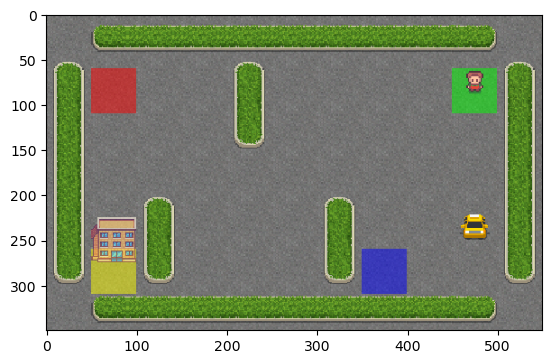

In [4]:
s, _ = env.reset(seed=SEED)
plt.imshow(env.render())

In [5]:
def play_and_train(env, agent, t_max=10**4):
    """
    Эта функция должна
    - запускать полноценную игру, выполняя действия, 
    указанные в политике e-greedy агента
    - обучать агента с помощью agent.update(...), когда это возможно
    - возвращает общее вознаграждение
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        # <YOUR CODE HERE>
        a = agent.get_action(s)

        # </END OF YOUR CODE>

        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated
        # train (update) agent for state s
        # <YOUR CODE HERE>
        agent.update(
            state=s, 
            action=a, 
            reward=r, 
            next_state=next_s
        )

        # </END OF YOUR CODE>

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

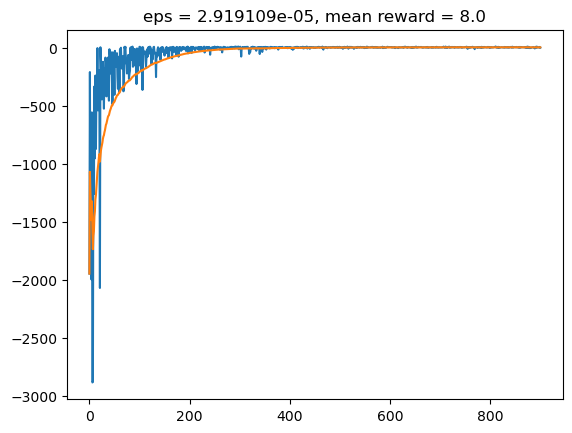

In [6]:
from IPython.display import clear_output

agent = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

rewards = []
seed_everything(env)

for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        plt.title("eps = {:e}, mean reward = {:.1f}".format(agent.epsilon, np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.plot(moving_average(rewards))
        plt.show()

assert env.unwrapped.spec.id == "Taxi-v3" and np.mean(rewards[-100:]) >= 4.5, (
    "Please make sure that your agent is able to learn the optimal policy"
)

# Seminar: Discretized state spaces

<!-- Use agent to train efficiently on `CartPole-v0`. This environment has a continuous set of possible states, so you will have to group them into bins somehow.

The simplest way is to use `round(x, n_digits)` (or `np.round`) to round a real number to a given amount of digits. The tricky part is to get the `n_digits` right for each state to train effectively.

Note that you don't need to convert state to integers, but to __tuples__ of any kind of values. -->

Используй агента, чтобы эффективно обучить его на среде `CartPole-v0`.
В этой среде пространство состояний является непрерывным,
поэтому тебе нужно разбить его на дискретные “корзины” (bins) каким-то образом.

Самый простой способ — использовать функцию round(x, n_digits) (или np.round),
чтобы округлить вещественное число до заданного количества знаков после запятой.

Хитрость в том, чтобы правильно подобрать n_digits для каждого компонента состояния,
чтобы обучение было эффективным.

Обрати внимание:
тебе не нужно преобразовывать состояние в целые числа —
достаточно сделать из него кортеж (tuple) из любых значений (например, округлённых чисел).

first state: [0.04746638 0.01390171 0.00297746 0.01816736]


/opt/anaconda3/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


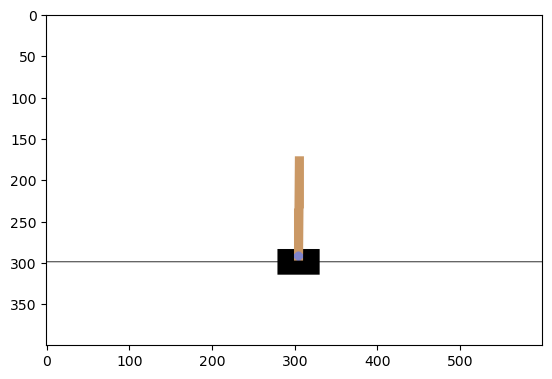

In [7]:
def make_env():
    return gym.make("CartPole-v0", render_mode="rgb_array").env  # .env unwraps the TimeLimit wrapper

env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())

### Play a few games

Нам нужно оценить распределение наблюдений. 

Для этого мы сыграем в несколько игр и запишем все состояния.

In [8]:
def visualize_cartpole_observation_distribution(seen_observations):
    seen_observations = np.array(seen_observations)

    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    # Get the number of dimensions from the state
    n_dims = seen_observations.shape[1]

    f, axarr = plt.subplots(1, n_dims, figsize=(16, 4), sharey=True)
    titles = ["Cart Position", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]

    for i in range(n_dims):
        ax = axarr[i]
        ax.hist(seen_observations[:, i], bins=20)
        ax.set_title(titles[i])
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

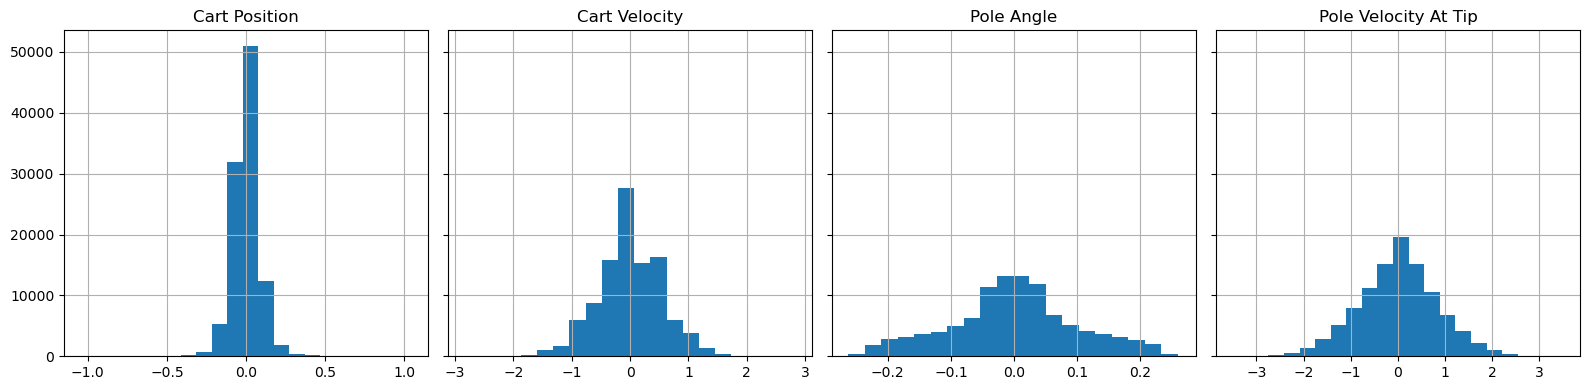

In [9]:
def gather_samples(env, max_steps=100000):
    seen_observations = []
    total_steps = 0

    while total_steps < max_steps:
        s, _ = env.reset()
        seen_observations.append(s)
        done = False

        while not done and total_steps < max_steps:
            s, r, done, _, _ = env.step(env.action_space.sample())
            seen_observations.append(s)
            total_steps += 1

        if total_steps >= max_steps:
            break

    return seen_observations


unwraped_env_samples = gather_samples(env)
visualize_cartpole_observation_distribution(unwraped_env_samples)

## Discretize environment

In [10]:
from gymnasium.core import ObservationWrapper


class Discretizer(ObservationWrapper):
    def __init__(self, env, n_digits):
        super().__init__(env)
        self.n_digits = n_digits

    def observation(self, state):
        # Подсказка: вы можете сделать это с помощью round(x, n_digits).
        # Вы можете выбрать разные n_digits для каждого измерения.

        # <YOUR CODE HERE>
        state = np.round(state, self.n_digits)

        # </END OF YOUR CODE>

        return tuple(state)  # tuple to make it hashable

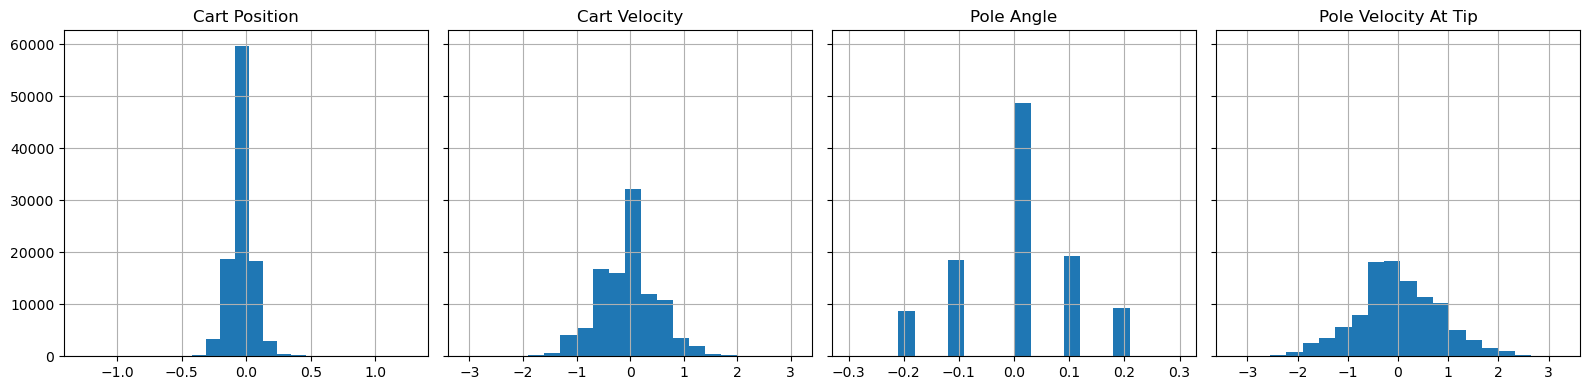

In [11]:
env = Discretizer(make_env(), n_digits=1)

seen_observations = gather_samples(env)
visualize_cartpole_observation_distribution(seen_observations)

## Learn discretized policy

Теперь давайте обучим политику, использующую **дискретизированное пространство состояний**.

---

### 💡 Советы

* Помните, что **увеличение числа знаков после запятой** для одного измерения наблюдения увеличивает размер пространства состояний в **10 раз**.
* Если ваша **дискретизация слишком детализирована**, агенту потребуется **значительно больше 10 000 шагов**, чтобы сойтись.  
  В этом случае можно либо **увеличить число итераций и уменьшить скорость затухания ε**, либо **сделать дискретизацию грубее**. На практике эта ошибка встречается довольно часто.
* Если ваша **дискретизация слишком грубая**, агент может **не найти оптимальную политику**. В этой конкретной среде такая ошибка встречается редко.
* **Начните с грубой дискретизации** и постепенно делайте её более точной, если это окажется необходимо.
* Рекомендуется иметь примерно **10³–10⁴ различных состояний** (`len(agent._qvalues)`), но это не обязательно.
* Если обучение не удается без постепенного уменьшения ε (annealing), подумайте о его добавлении, но убедитесь, что оно **не уменьшается слишком быстро**.

---

Агент с разумной стратегией должен достигать **среднего вознаграждения не менее 50**.


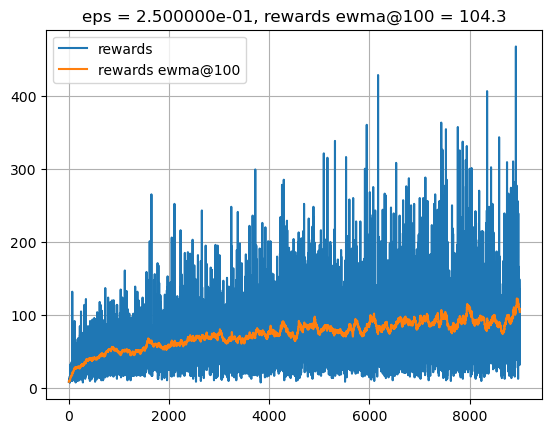

In [12]:
agent = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

rewards, epsilons = [], []
seed_everything(env)

for i in range(10000):
    reward = play_and_train(env, agent)
    rewards.append(reward)
    epsilons.append(agent.epsilon)

    # OPTIONAL: <YOUR CODE: adjust epsilon>

    if i % 1000 == 0:
        rewards_ewma = moving_average(rewards)

        clear_output(True)
        plt.plot(rewards, label="rewards")
        plt.plot(rewards_ewma, label="rewards ewma@100")
        plt.legend()
        plt.grid()
        plt.title("eps = {:e}, rewards ewma@100 = {:.1f}".format(agent.epsilon, rewards_ewma[-1]))
        plt.show()

## Homework Part I: On-policy learning and SARSA (3 points)

Политика, которую мы будем использовать, — это **ε-жадная политика (epsilon-greedy)**:  
агент выбирает **оптимальное действие** с вероятностью $(1-\epsilon)$,  
в противном случае — выбирает **случайное действие**.  

Обратите внимание, что агент **иногда может случайно выбрать оптимальное действие** даже при случайной выборке.

Теперь мы собираемся реализовать **Expected Value SARSA** поверх этой политики.

In [18]:
class EVSarsaAgent(QLearningAgent):
    """
    Агент, который изменяет некоторые функции Q-Learning для 
    реализации **Expected Value SARSA**.  

    Примечание: эта демонстрация предполагает, что ваша реализация 
    `QLearningAgent.update` использует `get_value(next_state)`.  

    Если это не так, добавьте метод:
    def update(self, state, action, reward, next_state):
        и реализуйте здесь Expected Value SARSA для V(s')
    """

    def get_value(self, state):
        """
        Returns Vpi for current state under epsilon-greedy policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        epsilon = self.epsilon
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # <YOUR CODE HERE>
        best_action = self.get_best_action(state)
        n_actions = len(possible_actions)
        state_value = 0.0
        for a in possible_actions:
            if a == best_action:
                pi = 1 - epsilon + epsilon / n_actions
            else:
                pi = epsilon / n_actions
            state_value += pi * self.get_qvalue(state, a)

        # </END OF YOUR CODE>

        return state_value

### Cliff World

Let's now see how our algorithm compares against q-learning in case where we force agent to explore all the time.

<img src=https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/cliffworld.png width=600>
<center><i>Image from CS188</i></center>

In [19]:
import gymnasium as gym

env = gym.make("CliffWalking-v1", render_mode="rgb_array")
n_actions = env.action_space.n


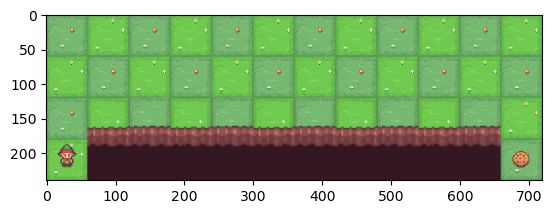

In [20]:
# Our cliffworld has one difference from what's in the image: there is no wall.
# Agent can choose to go as close to the cliff as it wishes.
# x:start, T:exit, C:cliff, o: flat ground

env.reset()
plt.imshow(env.render())

EVSARSA mean reward = -22.38
QLEARNING mean reward = -81.76


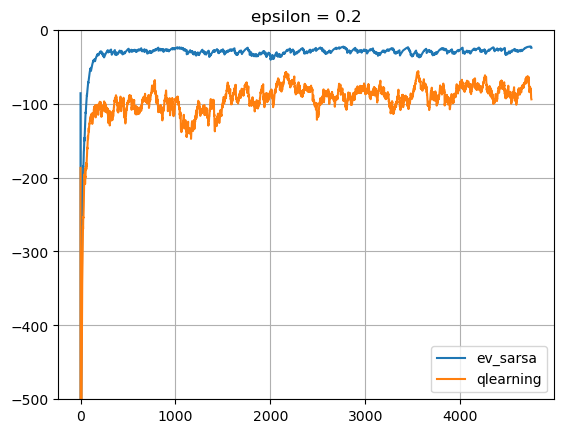

In [21]:
from IPython.display import clear_output

seed_everything(env)

agent_sarsa = EVSarsaAgent(alpha=0.25, epsilon=0.2, discount=0.99, env=env)

agent_ql = QLearningAgent(alpha=0.25, epsilon=0.2, discount=0.99, env=env)

rewards_sarsa, rewards_ql = [], []

for i in range(5000):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))
    # Note: agent.epsilon stays constant

    if i % 250 == 0:
        clear_output(True)
        print("EVSARSA mean reward =", np.mean(rewards_sarsa[-100:]))
        print("QLEARNING mean reward =", np.mean(rewards_ql[-100:]))
        plt.title("epsilon = %s" % agent_ql.epsilon)
        plt.plot(moving_average(rewards_sarsa), label="ev_sarsa")
        plt.plot(moving_average(rewards_ql), label="qlearning")
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

Давайте теперь посмотрим, чему научились алгоритмы, визуализируя их действия в каждом состоянии.

In [24]:
def get_ascii_policy(agent):
    """Returns CliffWalkingEnv policy with arrows as a string. Hard-coded."""

    env = gym.make("CliffWalking-v1", render_mode="ansi")
    env.reset()
    grid = [x.split("  ") for x in env.render().split("\n")[:4]]

    n_rows, n_cols = 4, 12
    start_state_index = 36
    actions = "^>v<"

    policy_str = ""
    for yi in range(n_rows):
        for xi in range(n_cols):
            if grid[yi][xi] == "C":
                policy_str += " C "
            elif (yi * n_cols + xi) == start_state_index:
                policy_str += " X "
            elif (yi * n_cols + xi) == n_rows * n_cols - 1:
                policy_str += " T "
            else:
                policy_str += " %s " % actions[agent.get_best_action(yi * n_cols + xi)]
        policy_str += "\n"

    return policy_str


def draw_policy(agent):
    """Prints CliffWalkingEnv policy with arrows."""
    print(get_ascii_policy(agent))

In [25]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

Q-Learning
 v  v  v  >  >  >  v  >  v  v  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 

SARSA
 >  >  >  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 



In [26]:
sarsa_near_cliff_row = get_ascii_policy(agent_sarsa).strip().split("\n")[-2].strip().split()[1:-3]
assert all(action == "^" for action in sarsa_near_cliff_row), (
    "SARSA policy should have '^' actions in the row near the cliff"
)

qlearning_near_cliff_row = get_ascii_policy(agent_ql).strip().split("\n")[-2].strip().split()[1:-3]
assert all(action == ">" for action in qlearning_near_cliff_row), (
    "Q-learning policy should have '>' actions in the row near the cliff"
)

## Expected Value SARSA for softmax policy (2 points)

Реализуйте агента, который будет использовать **softmax-политику** для выбора действий.  
Не забудьте также использовать softmax при вычислении **ожидаемого значения** для оценки состояния.  

Нарисуйте политику агента и посмотрите, отличается ли результат по сравнению с предыдущими подходами.  
Также попробуйте использовать разные значения температуры ($\tau$) и сравните результаты.


$$ \pi(a_i \mid s) = \operatorname{softmax} \left( \left\{ {Q(s, a_j) \over \tau} \right\}_{j=1}^n \right)_i = {\operatorname{exp} \left( Q(s,a_i) / \tau \right)  \over {\sum_{j}  \operatorname{exp} \left( Q(s,a_j) / \tau  \right)}} $$

In [27]:
def my_softmax(values: np.ndarray, T=1.):
    values = values - max(values)
    probas = np.zeros(values.shape[0])
    s = np.sum(np.exp(values / T))
    for i, value in enumerate(values):
        probas[i] = np.exp(value / T) / s
    assert probas is not None
    return probas

In [35]:
from scipy.special import softmax


class SoftmaxEVSarsaAgent(EVSarsaAgent):
    def __init__(self, alpha, tau, discount, env):
        super().__init__(alpha, None, discount, env)
        assert tau > 0
        self.tau = tau

    def get_softmax_policy(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        q_values = [self.get_qvalue(state, action) for action in possible_actions]
        q_values = np.asarray(q_values)
        assert q_values is not None
        probabilities = my_softmax(q_values)
        assert probabilities is not None
        return probabilities

    def get_value(self, state):
        """
        Returns V_{pi} for current state under softmax policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # <YOUR CODE HERE>
        q_values = np.asarray([
            self.get_qvalue(state, action) for action in possible_actions
        ])
        probabilities = self.get_softmax_policy(state)
        value = np.dot(q_values, probabilities)

        # </END OF YOUR CODE>

        return value

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        We should take a random action with probability equaled softmax of q values.
        """
        # Pick Action
        possible_actions = self.get_legal_actions(state)
        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # Tip: Use self.env.np_random.random() to generate a random number
        # <YOUR CODE HERE>
        probabilities = self.get_softmax_policy(state)
        chosen_action = np.random.choice(possible_actions, p=probabilities)
        # </END OF YOUR CODE>

        return chosen_action

EVSARSA mean reward = -25.21
SOFTMAX_EVSARSA mean reward = -17.7
QLEARNING mean reward = -80.62


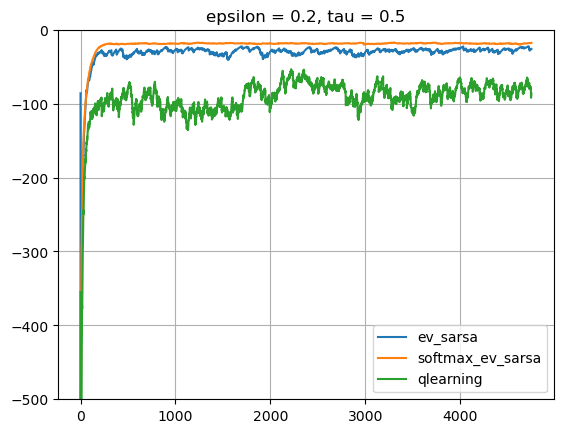

In [36]:
seed_everything(env)

agent_sarsa = EVSarsaAgent(alpha=0.25, epsilon=0.2, discount=0.99, env=env)

agent_sarsa_softmax = SoftmaxEVSarsaAgent(alpha=0.25, tau=0.5, discount=0.99, env=env)

agent_ql = QLearningAgent(alpha=0.25, epsilon=0.2, discount=0.99, env=env)

rewards_sarsa, rewards_sarsa_softmax, rewards_ql = [], [], []

for i in range(5000):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_sarsa_softmax.append(play_and_train(env, agent_sarsa_softmax))
    rewards_ql.append(play_and_train(env, agent_ql))

    if i % 250 == 0:
        clear_output(True)
        print("EVSARSA mean reward =", np.mean(rewards_sarsa[-100:]))
        print("SOFTMAX_EVSARSA mean reward =", np.mean(rewards_sarsa_softmax[-100:]))
        print("QLEARNING mean reward =", np.mean(rewards_ql[-100:]))
        plt.title("epsilon = %s, tau = %s" % (agent_ql.epsilon, agent_sarsa_softmax.tau))
        plt.plot(moving_average(rewards_sarsa), label="ev_sarsa")
        plt.plot(moving_average(rewards_sarsa_softmax), label="softmax_ev_sarsa")
        plt.plot(moving_average(rewards_ql), label="qlearning")
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

In [37]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

print("SOFTMAX SARSA")
draw_policy(agent_sarsa_softmax)

Q-Learning
 v  >  v  v  v  >  >  v  v  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 

SARSA
 >  >  >  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 

SOFTMAX SARSA
 >  >  >  >  >  >  >  >  v  v  v  v 
 >  >  >  >  >  >  >  >  >  >  v  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 



In [38]:
qlearning_near_cliff_row = get_ascii_policy(agent_sarsa_softmax).strip().split("\n")[-2].strip().split()[1:-3]
assert all(action == ">" for action in qlearning_near_cliff_row), (
    "Softmax SARSA policy should have '>' actions in the row near the cliff"
)

### More on SARSA

Вот несколько идей, чем можно заняться, если есть желание:

* Поиграйтесь с ε (epsilon). Посмотрите, как меняются обученные политики при установке ε на более высокие или низкие значения (например, 0.75).
* Реализуйте **N-step алгоритмы** и **TD(λ)**: см. главы 7 и 12 книги Саттона [Sutton's book](http://incompleteideas.net/book/RLbook2020.pdf).
* Используйте эти алгоритмы для обучения на **CartPole** в предыдущем или следующем задании этой недели.


## Часть II: experience replay (2 балла)

Существует мощная техника, которая позволяет повысить эффективность обучения для **off-policy алгоритмов**: [spoiler] **Experience replay** :)

Суть в том, что вы можете обучать **Q-learning** и **EV-SARSA** на `<s, a, r, s'>` кортежах, даже если они были получены не по текущей политике агента. Итак, что мы будем делать:

<img src="https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/exp_replay.png" width="480">

---

### Обучение с experience replay

1. Играем в игру, получаем кортеж `<s, a, r, s'>`.
2. Обновляем Q-значения на основе этого кортежа.
3. Сохраняем `<s, a, r, s'>` переход в буфер.
   - Если буфер заполнен, удаляем самые старые данные.
4. Берём случайные **K** переходов из буфера и обновляем Q-значения на их основе.

---

Чтобы включить такое обучение, сначала необходимо реализовать структуру памяти, которая будет действовать как **буфер переходов**.


In [39]:
from IPython.display import clear_output

In [102]:
import random


class ReplayBuffer(object):
    def __init__(self, size):
        """
        Создаём буфер воспроизведения (Replay buffer).

        Параметры
        ----------
        size: int
            Максимальное количество переходов, которое будет храниться в буфере. 
            Когда буфер переполняется, самые старые записи удаляются.

        Примечание:
        - Для этого задания можно выбрать любую структуру данных.
        - Если хотите сделать просто, можно хранить **список кортежей** `(s, a, r, s')` в `self._storage`.
        - Однако есть более быстрые и/или экономные по памяти способы хранения.
        """

        self._storage = []
        self._maxsize = size

        # OPTIONAL: YOUR CODE

    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        """
        Убедитесь, что размер `_storage` **не превышает** `_maxsize`.  
        Следите за правилом FIFO: **самые старые примеры удаляются первыми**.
        """
        data = (obs_t, action, reward, obs_tp1, done)

        # add data to storage
        # <YOUR CODE HERE>
        self._storage.append(data)

        if len(self._storage) > self._maxsize:
            self._storage.pop(0)
        # </END OF YOUR CODE>

    def sample(self, batch_size):
        """
        Выбираем случайную партию (batch) переходов.

        Параметры
        ----------
        batch_size: int
            Сколько переходов выбрать.

        Возвращаем
        ----------
        obs_batch: np.array
            Партия наблюдений (observations)
        act_batch: np.array
            Партия действий, выполненных для obs_batch
        rew_batch: np.array
            Партия наград, полученных за выполнение act_batch
        next_obs_batch: np.array
            Следующие наблюдения, полученные после выполнения act_batch
        done_mask: np.array
            done_mask[i] = 1, если выполнение act_batch[i] привело к завершению эпизода, иначе 0
        """


        # <YOUR CODE HERE>

        # <ВАШ КОД: случайным образом сгенерируйте batch_size целых чисел,  
        # которые будут использоваться как индексы выборки из буфера>

        buffer_size = len(self._storage)

        idxes = np.random.choice(
            buffer_size, 
            size=batch_size,
            # size=min(batch_size, buffer_size),
            # replace=False
        )

        # Соберем `<s, a, r, s', done>` для каждого индекса
        return (
            np.array([self._storage[i][0] for i in idxes]),
            np.array([self._storage[i][1] for i in idxes]),
            np.array([self._storage[i][2] for i in idxes]),
            np.array([self._storage[i][3] for i in idxes]),
            np.array([self._storage[i][4] for i in idxes]),
        )

        # </END OF YOUR CODE>

Некоторые тесты, чтобы убедиться, что ваш буфер работает правильно


In [103]:
def obj2arrays(obj):
    for x in obj:
        yield np.array([x])


def obj2sampled(obj):
    return tuple(obj2arrays(obj))


replay = ReplayBuffer(2)
obj1 = (0, 1, 2, 3, True)
obj2 = (4, 5, 6, 7, False)
replay.add(*obj1)
assert replay.sample(1) == obj2sampled(obj1), (
    "Если в буфере всего один объект, он должен быть возвращён при вызове `buf.sample(1)`)"
)

replay.add(*obj2)
assert len(replay) == 2, "Please make sure __len__ methods works as intended."
replay.add(*obj2)
assert len(replay) == 2, "When buffer is at max capacity, replace objects instead of adding new ones."
assert tuple(np.unique(a) for a in replay.sample(100)) == obj2sampled(obj2)
replay.add(*obj1)
assert max(len(np.unique(a)) for a in replay.sample(100)) == 2
replay.add(*obj1)
assert tuple(np.unique(a) for a in replay.sample(100)) == obj2sampled(obj1)
print("Success!")

Success!


Теперь давайте используем этот буфер для улучшения обучения:

In [104]:
import gymnasium as gym

env = gym.make("Taxi-v3")
# env = Discretizer(gym.make("CartPole-v1", render_mode="rgb_array"), n_digits=2)
n_actions = env.action_space.n

In [105]:
def play_and_train_with_replay(env, agent, replay=None, t_max=10**4, replay_batch_size=32):
    """
    Эта функция должна:
    - пройти полный эпизод игры, действия выбираются через `agent.get_action(s)`
    - обучать агента, используя `agent.update(...)` когда это возможно
    - возвращать суммарное вознаграждение (total reward)

    Параметр:
    - replay: `ReplayBuffer`, куда агент может сохранять и брать для обучения кортежи `(s, a, r, s', done)`.  
    Если `None`, experience replay не используется.
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s
        # <YOUR CODE HERE>
        a = agent.get_action(s)

        # </END OF YOUR CODE>

        next_s, r, done, trunc, _ = env.step(a)

        # update agent on current transition. Use agent.update
        # <YOUR CODE HERE>
        agent.update(s, a, r, next_s, done)
        # </END OF YOUR CODE>

        if replay is not None:
            # сохраним текущий переход <s,a,r,s'> в буфере
            # <YOUR CODE HERE>
            replay.add(s,a,r,next_s, done)
            # </END OF YOUR CODE>

            # выборка случайных переходов replay_batch_size из replay,
            # затем агент обновления для каждого из них в цикле
            s_, a_, r_, next_s_, done_ = replay.sample(replay_batch_size)

            print(s_)

            for i in range(replay_batch_size):
                # <YOUR CODE HERE>
                print(i)
                print(s_[i], a_[i], r_[i], next_s_[i], done_[i])
                agent.update(s_[i], a_[i], r_[i], next_s_[i], done_[i])
                # </END OF YOUR CODE>

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

In [106]:
# Create two agents: first will use experience replay, second will not.

agent_baseline = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

agent_replay = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

replay = ReplayBuffer(1000)

Baseline : eps = 2.9191091959171894e-05 mean reward = 9.2
ExpReplay: eps = 2.9191091959171894e-05 mean reward = 6.5


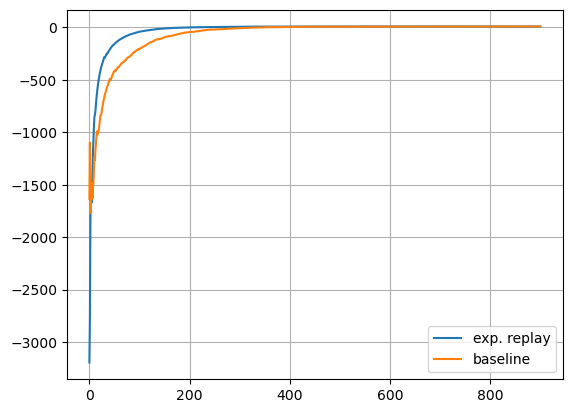

[473 216 242 409 261 139 377 277 119 316  57 146 259 278  46 136 393  87
 221 472 253  77 479 393 236 116 258 308 157  16 237 279]
0
473 4 -1 477 False
1
216 1 -1 116 False
2
242 3 -1 222 False
3
409 4 -1 417 False
4
261 3 -1 241 False
5
139 0 -1 239 False
6
377 1 -1 277 False
7
277 1 -1 177 False
8
119 2 -1 139 False
9
316 1 -1 216 False
10
57 2 -1 77 False
11
146 1 -1 46 False
12
259 2 -1 279 False
13
278 3 -1 258 False
14
46 2 -1 66 False
15
136 3 -1 116 False
16
393 0 -1 493 False
17
87 4 -1 99 False
18
221 1 -1 121 False
19
472 4 -1 476 False
20
253 2 -1 273 False
21
77 2 -1 97 False
22
479 5 20 475 True
23
393 0 -1 493 False
24
236 1 -1 136 False
25
116 1 -1 16 False
26
258 3 -1 238 False
27
308 0 -1 408 False
28
157 1 -1 57 False
29
16 5 20 0 True
30
237 2 -1 257 False
31
279 0 -1 379 False
[318 274  57 474 418 199 318 218 212 218 207  16 259 279 262  51 239 237
 223 218   6 279 209  99 376 212 177 279 103 379  98 402]
0
318 0 -1 418 False
1
274 0 -1 374 False
2
57 2 -1 77 False

In [107]:
import pandas as pd
from IPython.display import clear_output


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


rewards_replay, rewards_baseline = [], []

for i in range(1000):
    rewards_replay.append(play_and_train_with_replay(env, agent_replay, replay))
    rewards_baseline.append(play_and_train_with_replay(env, agent_baseline, replay=None))

    agent_replay.epsilon *= 0.99
    agent_baseline.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        print(
            "Baseline : eps =",
            agent_replay.epsilon,
            "mean reward =",
            np.mean(rewards_baseline[-10:]),
        )
        print(
            "ExpReplay: eps =",
            agent_baseline.epsilon,
            "mean reward =",
            np.mean(rewards_replay[-10:]),
        )
        plt.plot(moving_average(rewards_replay), label="exp. replay")
        plt.plot(moving_average(rewards_baseline), label="baseline")
        plt.grid()
        plt.legend()
        plt.show()

assert np.array(rewards_replay[:200]).mean() > np.array(rewards_baseline[:200]).mean(), (
    "Experienced replay should improve performance"
)

#### What to expect:


Если experience replay реализован правильно, он **значительно ускорит начальную сходимость алгоритма**, но **не должен влиять на конечное качество**.  

Если вам нужно больше примеров, чтобы понять, как работает experience replay, попробуйте использовать его для **дискретизированных пространств состояний** (CartPole или другие __[классические среды управления](https://gym.openai.com/envs/#classic_control)__).


# N-step TD learning

В этой части мы познакомимся с multi-step estimates. 

Мы начнем с **on-policy** настройки, но в качестве бонуса вы также можете реализовать **off-policy** версию.

Напомним, что **TD(0)** оценки имеют **низкую дисперсию**, но **высокую смещенность**, в то время как оценки на основе **полной траектории** имеют **низкую смещенность**, но **высокую дисперсию**. Для многих задач оптимальный подход находится **где-то посередине** между этими крайностями. Методы с n-шагами (**N-step methods**) предоставляют эту **среднюю точку**, позволяя нам **контролировать баланс смещенности и дисперсии** через выбор n.

Анализ производительности при разных значениях n-шагов может быть сложным из-за шумных наград. В этом случае используйте функцию `benchmark_agents`, которая позволяет визуализировать производительность по нескольким запуском (multi-seed).

### N-step EV-SARSA (2 балла)

[Смотрите раздел 7.2 в книге Sutton & Barto](http://incompleteideas.net/book/the-book-2nd.html)

**Обычный n-шаг TD** (без эпизодического буфера):

Для каждого шага $t$ берём будущий интервал $[t, t+n]$ (если доступен) и вычисляем:

$$
G_t = r_t + \gamma r_{t+1} + \cdots + \gamma^{n-1} r_{t+n-1} + \gamma^n V(s_{t+n})
$$

Расчёт выполняется **слева направо** (по мере накопления данных). Если эпизод заканчивается раньше, берём фактическую длину оставшейся траектории.


---

### n-step Sarsa для оценки $Q \approx q_* \text{ или } q_\pi$

- Инициализируем $Q(s,a) \quad \forall s \in \mathcal{S}, a \in \mathcal{A}$.
- Инициализируем $\pi$ как $\varepsilon$-жадную политику относительно $Q$, или как фиксированную заданную политику.
- Параметры алгоритма: 
  - шаг обучения $\alpha \in (0,1]$
  - маленькое $\varepsilon > 0$
  - положительное целое число $n$
- Все операции хранения и доступа (для $S_t$, $A_t$ и $R_t$) могут использовать индекс по модулю $n+1$.


Для каждого эпизода:
- Инициализируем и сохраняем $S_0 \neq \text{terminal}$.
- Выбираем и сохраняем действие $A_0 \sim \pi(\cdot|S_0)$.
- $T \leftarrow \infty$






Для $t = 0,1,2,\dots$:
- Если $t < T$:
  - Выполняем действие $A_t$.
  - Наблюдаем и сохраняем следующую награду $R_{t+1}$ и следующее состояние $S_{t+1}$.
  - Если $S_{t+1}$ терминальное, устанавливаем $T \leftarrow t + 1$.
  - Иначе выбираем и сохраняем действие $A_{t+1} \sim \pi(\cdot|S_{t+1})$.

- $\tau \leftarrow t - n + 1$ (время, для которого обновляется оценка).

- Если $\tau \geq 0$:
  - $G \leftarrow \sum_{i=\tau+1}^{\min(\tau+n,T)} \gamma^{i-\tau-1} R_i$.
  - Если $\tau + n < T$, тогда $G \leftarrow G + \gamma^n Q(S_{\tau+n}, A_{\tau+n}) \quad (G_{\tau:\tau+n})$.
  - $Q(S_\tau,A_\tau) \leftarrow Q(S_\tau,A_\tau) + \alpha[G - Q(S_\tau,A_\tau)]$.
  - Если $\pi$ обучается, обеспечиваем, чтобы $\pi(\cdot|S_\tau)$ оставалась $\varepsilon$-жадной относительно $Q$.

- Если $\tau = T - 1$, прерываем цикл.

---

Так как мы работаем с `EV-SARSA`, будет небольшое отличие:

Он состоит из линейной последовательности действий и состояний, как в `n-step Sarsa`, за исключением того, что последний элемент является ветвлением по всем возможным действиям, взвешенным по их вероятности под $\pi$. 

Этот алгоритм можно описать той же формулой, что и `n-step Sarsa` (выше), за исключением того, что **n-шаговая доходность** определяется как

$$
G_{t:t+n} \doteq R_{t+1} + \dots + \gamma^{n-1} R_{t+n} + \gamma^n \bar{V}_{t+n-1}(S_{t+n}),
\quad t + n < T,
$$

(с $ G_{t:t+n} \doteq G_t $ для $ t + n \geq T $), где $\bar{V}_t(s)$ — это **ожидаемое приближённое значение** состояния $s$, вычисляемое с использованием оценок действий в момент $t$ под целевой политикой:

$$
\bar{V}_t(s) \doteq \sum_a \pi(a|s) Q_t(s, a), \quad \text{для всех } s \in \mathcal{S}.
$$

Ожидаемые приближённые значения используются при разработке многих методов оценки действий в остальной части книги. Если $s$ терминальное, его ожидаемое приближённое значение определяется как 0.

In [135]:
from collections import deque, namedtuple

Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class NStepEVSarsaAgent(EVSarsaAgent):
    def __init__(self, n_steps, *args, **kwargs):
        assert n_steps >= 1, "n_step must be greater than or equal to 1"
        super().__init__(*args, **kwargs)
        self.n_steps = n_steps
        self.t = 0  # aka current step
        self.T = sys.maxsize  # aka terminal step
        self.memory = []

    def update(self, state, action, reward, next_state, done):
        if len(self.memory) == 0:
            self.memory.append(Transition(state, action, reward, next_state, done))
            return

        if self.t < self.T:
            self.memory.append(Transition(state, action, reward, next_state, done))

            if done:
                self.T = self.t + 1

        tau = self.t - self.n_steps
        if tau >= 0:
            start_index, end_index = tau + 1, min(tau + self.n_steps, self.T)
            G = 0

            # <YOUR CODE HERE>
            # G = sum(discount^k * reward)
            for k, index in enumerate(range(start_index, end_index)):
                G += self.discount ** k * self.memory[index].reward
            # </END OF YOUR CODE>
        
            expected_q = 0
            if tau + self.n_steps < self.T:
                next_s = self.memory[tau + self.n_steps].next_state
                if next_s is not None:
                
                # <YOUR CODE HERE>
                    # G += gamma^n * sum(pi * Q)
                    best_action = self.get_best_action(next_s)
                    actions = self.get_legal_actions(next_s)
                    for action in actions:
                        q = self.get_qvalue(next_s, action)
                        if action == best_action:
                            prob = (1 - self.epsilon) + self.epsilon / len(actions)
                        else:
                            prob = self.epsilon / len(actions)
                        expected_q += prob * q
                G += (self.discount ** self.n_steps) * expected_q
                # </END OF YOUR CODE>

            state_tau, action_tau = (
                self.memory[tau].state,
                self.memory[tau].action,
            )  # state and action to being updated

            # <YOUR CODE HERE>
            # Q(S,A) = Q(S,A) + alpha[G - Q(S,A)]
            old_q = self.get_qvalue(state_tau, action_tau)
            new_qvalue = old_q + self.alpha * (G - old_q)
            # </END OF YOUR CODE>
            
            self.set_qvalue(state_tau, action_tau, new_qvalue)
        self.t += 1

        if self.t >= self.T and tau < self.T - 1:
            self.update(
                self.memory[self.T - 1].state, 
                self.memory[self.T - 1].action, 
                0, None, True)

    def reset(self):
        self.memory = []
        self.t = 0
        self.T = sys.maxsize


def play_and_train_nstep(env, agent, t_max=10**4):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()
    agent.reset()

    for t in range(t_max):
        # get agent to pick action given state s
        a = agent.get_action(s)

        next_s, r, terminated, truncated, info = env.step(a)
        done = terminated

        # train (update) agent for state s
        agent.update(s, a, r, next_s, done)

        s = next_s
        total_reward += r
        if done:
            agent.reset()
            break

    return total_reward

In [136]:
from functools import partial


def evaluate_nstep_evsarsa(env_builder, n_episodes=1000, t_max=10000, n_seeds=3, span=10):
    params = {"alpha": 0.1, "epsilon": 0.1, "discount": 0.99, "env": env_builder()}

    exp_setups = [
        {
            "name": f"nstep_evsarsa_{n_step}",
            "agent_builder": partial(NStepEVSarsaAgent, n_steps=n_step, **params),
            "env": env_builder,
            "train_foo": play_and_train_nstep,
        }
        for n_step in [1, 2, 4]
    ]
    _ = benchmark_agents(
        exp_setups, num_episodes=n_episodes, t_max=t_max, plot_every=1000, span=span, num_seeds=n_seeds
    )

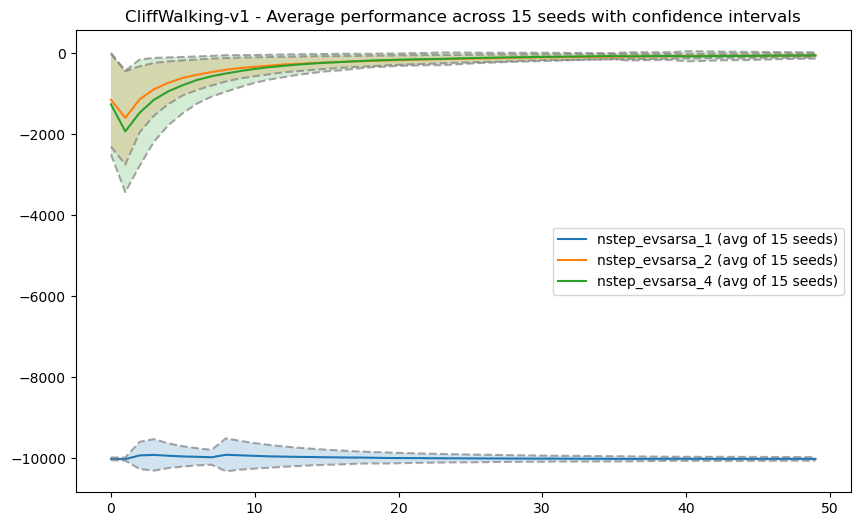

In [137]:
evaluate_nstep_evsarsa(lambda: gym.make("CliffWalking-v1"), n_episodes=50, t_max=1000, n_seeds=15, span=25)

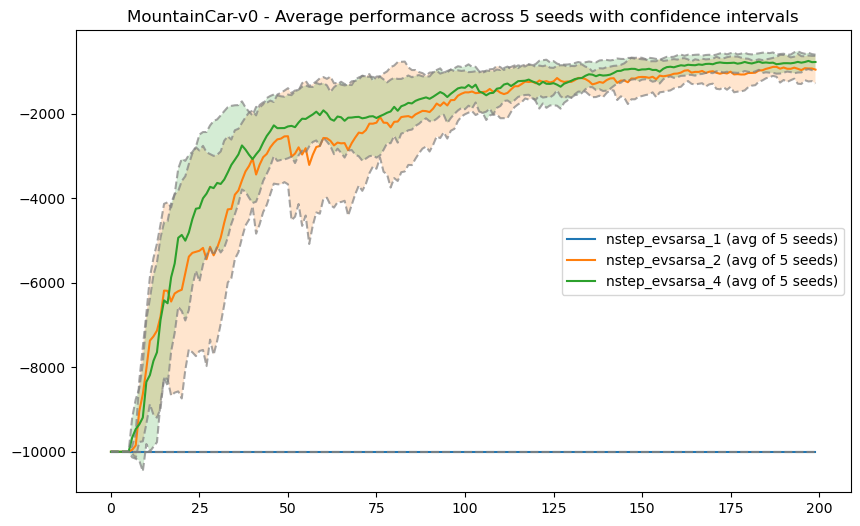

In [138]:
evaluate_nstep_evsarsa(lambda: Discretizer(gym.make("MountainCar-v0"), n_digits=2), n_episodes=200, n_seeds=5)

## Eligibility traces: (1 point)

`Eligibility traces` — это механизм, который помогает распределять «заслугу» между состояниями и действиями, произошедшими в прошлом. Это позволяет более эффективно обучаться, так как несколько пар «состояние–действие» могут обновляться за один шаг.

Обычно трейсы правдоподобия реализуются как затухающие значения для каждой пары «состояние–действие»: более недавние пары имеют больший след (trace), чем более старые. В начале каждого эпизода все трейсы инициализируются нулями, а в конце эпизода — сбрасываются, чтобы подготовиться к следующей последовательности обучения.

На каждом шаге трейсы обновляются: значение для текущей пары «состояние–действие» увеличивается, а ко всем следам применяется коэффициент затухания. Это позволяет алгоритму обновлять все ранее посещённые пары пропорционально их недавности и значимости.

---

### Watkins($\lambda$) algorithm
**Initialize** $ Q(s, a) $ arbitrarily and $ e(s, a) = 0 $, for all $ s, a $.

**Repeat** (for each episode):

1. Initialize $ s, a $.
2. **Repeat** (for each step of episode):
   - Take action $ a $, observe $ r, s' $.
   - Choose $ a' $ from $ s' $ using policy derived from $ Q $ (e.g., $ \varepsilon $-greedy).
   - $ a^* \leftarrow \arg\max_b Q(s', b) $ (if $ a' $ ties for the max, then $ a^* \leftarrow a' $).
   - $ \delta \leftarrow r + \gamma Q(s', a^*) - Q(s, a) $.
   - $ e(s, a) \leftarrow e(s, a) + 1 $.
   - **For all** $ s, a $:
     - $ Q(s, a) \leftarrow Q(s, a) + \alpha \delta e(s, a) $.
     - If $ a' = a^* $, then $ e(s, a) \leftarrow \gamma \lambda e(s, a) $,  
       else $ e(s, a) \leftarrow 0 $.
   - $ s \leftarrow s' $; $ a \leftarrow a' $.

**until** $ s $ is terminal.

---

We have two policies: the target policy (greedy) and the behavior policy (ε-greedy).

Watkins' Q(λ) algorithm addresses the challenge of using eligibility traces in off-policy learning. The key insight is that we can only reliably update state-action pairs along a trajectory up to the point where we take a non-greedy action.

When we select an action a' that is also the greedy action a* (meaning our behavior and target policies align), we can continue propagating updates through the eligibility traces, decaying them by γλ as usual.
 
However, when we select a non-greedy action (a' ≠ a*), we must cut the eligibility traces to zero. This is because the future trajectory will follow the behavior policy, not the target policy we're trying to learn.
 
This approach ensures that Q-values are only updated based on sequences where the behavior matched the target policy, maintaining the validity of the off-policy updates while still benefiting from eligibility traces when possible.




In [ ]:
from collections import defaultdict


class QLambdaAgent(QLearningAgent):
    def __init__(self, alpha, epsilon, discount, lambda_factor, env):
        assert 0 <= lambda_factor <= 1, "lambda must be between 0 and 1"
        super().__init__(alpha, epsilon, discount, env)
        self.eligibility_trace = defaultdict(lambda: 0)
        self.lambda_factor = lambda_factor

    def reset(self):
        pass

    def update(self, state, action, reward, next_state, _done):
        """
        Implements Q(λ) update rule:
        - Updates Q-values using eligibility traces.
        - Adjusts traces based on whether the selected action matches the best action.
        """
        # Update eligibility traces
        for s, a in list(self.eligibility_trace.keys()):
            if action == self.get_best_action(state):
                # Decay eligibility trace (but never immediately zero it)
                # <YOUR CODE HERE>

                # </END OF YOUR CODE>
            else:
                # <YOUR CODE HERE>

                # </END OF YOUR CODE>

            # Remove traces close to zero
            if abs(self.eligibility_trace[(s, a)]) < 1e-6:
                del self.eligibility_trace[(s, a)]

        # Compute TD error with check for terminal state
        next_value = self.get_value(next_state) if next_state is not None else 0
        delta = reward + self.discount * next_value - self.get_qvalue(state, action)

        # Update eligibility trace for (state, action)
        # <YOUR CODE HERE>

        # </END OF YOUR CODE>

        # Iterate over all stored (s, a) pairs in eligibility trace
        for s, a in list(self.eligibility_trace.keys()):
            # <YOUR CODE HERE>
            new_qvalue =

            # </END OF YOUR CODE>
            self.set_qvalue(s, a, new_qvalue)

In [ ]:
from functools import partial


def evaluate_lambda_qlearning(env_builder, n_episodes=1000, t_max=10000, n_seeds=3, span=10):
    params = {"alpha": 0.1, "epsilon": 0.1, "discount": 0.99, "env": env_builder()}
    exp_setups = []
    exp_setups.extend(
        [
            {
                "name": f"lambda_qlearning_{lambda_factor}",
                "agent_builder": partial(QLambdaAgent, lambda_factor=lambda_factor, **params),
                "env": env_builder,
                "train_foo": play_and_train_nstep,
            }
            for lambda_factor in [0.0, 0.2, 0.5, 0.95]
        ]
    )
    _ = benchmark_agents(
        exp_setups, num_episodes=n_episodes, t_max=t_max, plot_every=1000, span=span, num_seeds=n_seeds
    )

In [ ]:
evaluate_lambda_qlearning(lambda: gym.make("CliffWalking-v0"), n_episodes=150, t_max=1000, n_seeds=15, span=20)

In [ ]:
evaluate_lambda_qlearning(lambda: gym.make("Taxi-v3"), n_episodes=150, t_max=1000, n_seeds=15, span=20)

In [ ]:
evaluate_lambda_qlearning(lambda: Discretizer(gym.make("MountainCar-v0"), n_digits=2), n_episodes=200, n_seeds=5)

## N-step estimates in off-policy setting. Retrace algorithm. (3-5 points)

Implement Retrace algorithm and use it with Replay Buffer

## Understanding Retrace(λ)

Retrace(λ) is an off-policy reinforcement learning algorithm that combines the benefits of eligibility traces with importance sampling to provide stable and efficient learning from off-policy data.

### Key Features of Retrace

1. **Off-policy Learning**: Retrace can learn from data generated by any behavior policy, making it suitable for experience replay.

2. **Eligibility Traces**: Like TD(λ), Retrace uses eligibility traces to credit past state-action pairs, allowing for faster learning.

3. **Truncated Importance Sampling**: The key innovation in Retrace is the use of truncated importance sampling ratios ($\min(1, \frac{\pi(a|s)}{\mu(a|s)})$), which ensures the product of these ratios doesn't grow too large and cause variance issues.

### The Retrace Update Rule

Retrace maintains a running return estimate $Q^{ret}$ defined recursively:

$$Q^{ret}(s_t, a_t) = r_t + \gamma[(1-\alpha)Q(s_{t+1}, a_{t+1}) + \alpha(Q(s_{t+1}, a_{t+1}) + c_{t+1}\lambda\delta_{t+1})]$$

Where:
- $c_{t+1} = \min(1, \frac{\pi(a_{t+1}|s_{t+1})}{\mu(a_{t+1}|s_{t+1})})$ is the truncated importance sampling ratio
- $\delta_{t+1} = Q^{ret}(s_{t+1}, a_{t+1}) - Q(s_{t+1}, a_{t+1})$ is the TD error for the next state-action pair
- $\lambda$ is the trace decay parameter

This update effectively combines:
- Q-learning's off-policy capability
- SARSA's ability to use eligibility traces
- Stability through truncated importance sampling

### Advantages Over Traditional Methods

1. **Compared to Q-learning**: Retrace incorporates multi-step returns through eligibility traces, which can lead to faster convergence in many environments.

2. **Compared to SARSA(λ)**: Retrace is off-policy, so it can learn from exploratory actions without being affected by them.

3. **Compared to Importance Sampling Methods**: By truncating the importance ratios, Retrace avoids the high variance issues that plague many importance sampling approaches.

### Applications

Retrace is particularly well-suited for:
- Experience replay settings
- Learning from human demonstrations
- Any setting where on-policy data collection is expensive or impractical

## Task

Compare different Retrace methods: without Importance Sampling, with Importance Sampling, and with Retrace. Ensure the differences are noticeable. Test different training settings, such as collecting trajectories with one agent and using them to initialize Retrace. Collect several episodes using a uniform policy and use them to initialize the buffer. Analyze performance and convergence.

In [ ]:
def play_and_train_retrace(env, agent, replay, t_max, n_train_steps, trajectory_len):
    total_reward = 0.0
    s, _ = env.reset()
    replay._episodes.append([])

    for t in range(t_max):
        # Get action from agent
        a = agent.get_action(s)
        prob = agent.get_action_probability(s, a)

        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        replay._episodes[-1].append((s, a, r, next_s, done, prob))

        # Update state and total reward
        s = next_s
        total_reward += r

        if replay is not None and len(replay) > 0:
            for _ in range(n_train_steps):
                trajectory = replay.sample(max_trajectory_len=trajectory_len)  # whole trajectory
                agent.retrace_update(trajectory)

        if done:
            break

    return total_reward

In [ ]:
from collections import deque


class SequenceBuffer:
    def __init__(self, episode_capacity):
        self._episodes = deque(maxlen=episode_capacity)

    def __len__(self):
        return len(self._episodes)

    def add_sequence(self, sequence):
        self._episodes.append(sequence)

    def sample(self, max_trajectory_len=None):
        seq_idx = np.random.randint(0, len(self))
        sequence = self._episodes[seq_idx]

        if max_trajectory_len is None:
            return sequence

        start_idx = np.random.randint(0, max(len(sequence) - max_trajectory_len, 1))
        return sequence[start_idx : start_idx + max_trajectory_len]

In [ ]:
class RetraceAgent(QLearningAgent):
    def __init__(self, alpha, epsilon, discount, env, lambda_factor=0.9):
        super().__init__(alpha, epsilon, discount, env)
        self.lambda_factor = lambda_factor

    def get_action_probability(self, state, action):
        # <YOUR CODE HERE>

        # </END OF YOUR CODE>

    def retrace_update(self, trajectory):
        last_state, last_action, last_reward, last_next_state, last_done, last_behavior_prob = trajectory[-1]

        # <YOUR CODE HERE>
        G =

        # </END OF YOUR CODE>

        for state, action, reward, next_state, done, behavior_prob in reversed(trajectory[:-1]):
            # <YOUR CODE HERE>
            c =

            # </END OF YOUR CODE>
            if done:
                expected_Q = 0
            else:
                probs = [self.get_action_probability(state, action) for action in self.get_legal_actions(state)]
                # <YOUR CODE HERE>
                expected_Q =

                # </END OF YOUR CODE>

            # <YOUR CODE HERE>
            G =

            # </END OF YOUR CODE>

            # <YOUR CODE HERE>
            new_q_value =

            # </END OF YOUR CODE>
            self.set_qvalue(state, action, new_q_value)

In [ ]:
env = gym.make("CliffWalking-v0")

agent_baseline = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)

agent_replay = QLearningAgent(alpha=0.5, epsilon=0.25, discount=0.99, env=env)
replay = ReplayBuffer(1000)

sequence_buffer = SequenceBuffer(1000)
retrace_agent = RetraceAgent(alpha=0.25, epsilon=0.25, discount=0.99, env=env, lambda_factor=0.9)

rewards_replay, rewards_baseline, rewards_retrace = [], [], []

t_max = 100
for i in trange(300):
    rewards_replay.append(play_and_train_with_replay(env, agent_replay, replay, t_max=t_max))
    rewards_baseline.append(play_and_train_with_replay(env, agent_baseline, replay=None, t_max=t_max))
    rewards_retrace.append(
        play_and_train_retrace(env, retrace_agent, sequence_buffer, t_max=t_max, trajectory_len=8, n_train_steps=32)
    )

    if i % 10 == 0:
        clear_output(True)
        print("Baseline : eps =", agent_replay.epsilon, "mean reward =", np.mean(rewards_baseline[-10:]))
        print("ExpReplay: eps =", agent_baseline.epsilon, "mean reward =", np.mean(rewards_replay[-10:]))
        print("Retrace: eps =", retrace_agent.epsilon, "mean reward =", np.mean(rewards_retrace[-10:]))
        plt.plot(moving_average(rewards_replay, span=50), label="exp. replay")
        plt.plot(moving_average(rewards_baseline, span=50), label="baseline")
        plt.plot(moving_average(rewards_retrace, span=50), label="retrace")
        plt.grid()
        plt.legend()
        plt.show()

**Bonus:** You can also analyze the performance of different agents with different hyperparameters across various environments. For the N-step bonus, it would be interesting to show how the variance and bias of Q-values depend on nn.


### Outro

We will use the code you just wrote extensively in the next week of our course. 

__Next week__ we're gonna explore how q-learning and similar algorithms can be applied for large state spaces, with deep learning models to approximate the Q function.

However, __the code you've written__ for this week is already capable of solving many RL problems, and as an added benefit - it is very easy to detach. You can use Q-learning, SARSA and Experience Replay for any RL problems you want to solve - just thow 'em into a file and import the stuff you need.